In [ ]:
# DEUTSCH ALGORITHM
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def deutsch(case: int) -> QuantumCircuit:
    """Creates quantum circuit for one of the four functions from one bit to one bit"""
    if case not in range(4):
        raise ValueError()
    f = QuantumCircuit(2)
    if case in [1, 2]:
        f.cx(0, 1)
    if case in [2, 3]:
        f.x(1)
    return f


def compile(fun: QuantumCircuit) -> QuantumCircuit:
    """Compiles circuit for Deutsch's algorithm"""
    n = fun.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(fun, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc


def deutsch_algo(fun: QuantumCircuit) -> str:
    """Run Deutsch's algorithm on a one bit function"""
    result = AerSimulator().run(compile(fun), shots=1, memory=True).result().get_memory()[0]
    if result == "0":
        return "constant"
    return "balanced"


for i in range(4):
    print(deutsch_algo(deutsch(i)))

In [ ]:
# DEUTSCH-JOZSA
from qiskit import QuantumCircuit
from numpy.random import randint, choice
from qiskit_aer import AerSimulator


def query_dj(num_qubits: int) -> QuantumCircuit:
    """Creates a random circuit for Deutch-Jozsa"""
    qc = QuantumCircuit(num_qubits + 1)
    if randint(0, 2):
        qc.x(num_qubits)  # Randomly flip output
    if randint(0, 2):
        return qc  # 50% a constant circuit
    on_states = choice(range(2**num_qubits), 2**num_qubits // 2, replace=False)  # Randomly choose half the states to put to 1

    def add_cx(qc: QuantumCircuit, bit_string: str) -> QuantumCircuit:
        """Add X gates according to bit_string"""
        for qubit, bit in enumerate(bit_string[::-1]):
            if bit == '1':
                qc.x(qubit)
        return qc

    for state in on_states:
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")
    return qc


def compile_dj(fun: QuantumCircuit) -> QuantumCircuit:
    """Compile fun to a Deutsch-Jozsa circuit"""
    n = fun.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(fun, inplace=True)
    qc.h(range(n))
    qc.barrier()
    qc.measure(range(n), range(n))
    return qc


def dj_algo(fun: QuantumCircuit) -> str:
    """Run Deutsch-Algorithm on fun"""
    result = AerSimulator().run(compile_dj(fun), shots=1, memory=True).result().get_memory()[0]
    if "1" in result:
        return "balanced"
    return "constant"

In [ ]:
# BERNSTEIN-VAZIRANI
def query_bv(s: str):
    """Creates a Bernstein-Vazirani query gate"""
    print(s)
    qc = QuantumCircuit(len(s) + 1)
    for qubit, bit in enumerate(s[::-1]):
        if bit == "1":
            qc.cx(qubit, len(s))
    return qc


circ = compile_dj(query_bv(f"{3022006:0b}"))
display(AerSimulator().run(circ, shots=1, memory=True).result().get_memory()[0])
display(circ.draw('mpl', fold=-1))

In [ ]:
# SIMON
from qiskit import QuantumCircuit


def simon_oracle(b: str) -> QuantumCircuit:
    """Creates a Simon oracle for b"""
    b = b[::-1]  # reverse b for easy iteration
    n = len(b)
    qc = QuantumCircuit(n * 2)
    # Do copy; |x>|0> -> |x>|x>
    for q in range(n):
        qc.cx(q, q + n)
    if '1' not in b:
        return qc  # 1:1 mapping, so just exit
    i = b.find('1')  # index of first non-zero bit in b
    # Do |x> -> |s.x> on condition that q_i is 1
    for q in range(n):
        if b[q] == '1':
            qc.cx(i, (q) + n)
    return qc


def simon_algorithm(fun: QuantumCircuit, n: int, m: int) -> QuantumCircuit:
    assert fun.num_qubits == n + m
    qc = QuantumCircuit(m + n, n)
    qc.h(range(n))
    qc.compose(fun, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

In [ ]:
# QUANTUM FOURIER TRANSFORM
from math import pi
from qiskit import QuantumCircuit
from qiskit.circuit import Gate


def qft(n: int) -> QuantumCircuit:
    assert n > 0
    qc = QuantumCircuit(n)
    if n == 1:  # qft on one qubit is just hadamard
        qc.h(0)
        return qc
    # qft on n qubit starts with qft on n-1 bits
    qc.compose(qft(n - 1), range(1, n), inplace=True)
    # then phase is injected with controlled P gate
    for i in range(n - 1):
        ang = pi / (2**(n - i - 1))
        qc.cp(ang, 0, i + 1)
    # hadamard on top qubit
    qc.h(0)
    # swap first and last qubit and shift everyone else up
    qc.swap(0, n - 1)
    for i in range(n - 2):
        qc.swap(i, i + 1)
    return qc


def qft_gate(n: int) -> Gate:
    return qft(n).to_gate(label=f"QFT_2^{n}")


def iqft_gate(n: int) -> Gate:
    return qft(n).inverse().to_gate(label=rf"$\text{{QFT}}_{{2^{n}}}†$")

In [ ]:
# PHASE ESTIMATION
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit import Gate
from qiskit.circuit.library import XGate


def naive_phase_estimation(gate: Gate, psi: Statevector, m: int) -> QuantumCircuit:
    assert m >= 0
    assert gate.num_qubits == psi.num_qubits
    assert psi.num_qubits is not None
    qc = QuantumCircuit(m + gate.num_qubits, m)
    psi_qubits = list(range(m, m + psi.num_qubits))
    qc.initialize(psi, psi_qubits)
    qc.h(range(m))
    c_gate = gate.control()
    for i in range(m):
        power = c_gate.power(2**i)
        if i <= 4:
            power.label = rf"${c_gate.name}^{{{2**i}}}$"
        else:
            power.label = rf"${c_gate.name}^{{2^{i}}}$"
        qc.append(power, [i, *psi_qubits])
    qc.append(iqft_gate(m), range(m))
    qc.measure(range(m), range(m))
    return qc


qc = naive_phase_estimation(XGate(), Statevector.from_label("0"), 5)
qc_ = qc  # .decompose()
display([d.operation.name for d in qc_.data])
qc_.draw('mpl')


16

2

{'barrier', 'circuit-205', 'h', 'measure'}

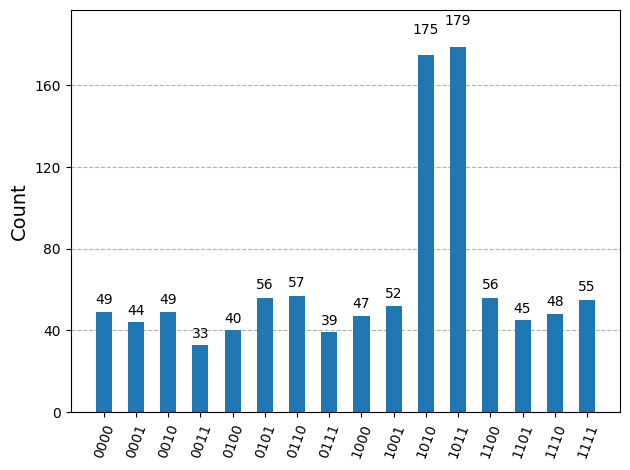

In [ ]:
# GROVER
from math import ceil, sqrt, pi
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def grover_oracle(states: list[str]) -> tuple[QuantumCircuit, int]:
    """Marks states as accepted by Grover's algorithm"""
    assert len(states) > 0, "Can't work without marked states"
    bits = len(states[0])
    oracle = QuantumCircuit(bits)
    for state in states:
        assert len(state) == bits
        # Flip qubits where states = 0 (work on reversed state because of qiskit convention)
        for qubit, bit in enumerate(state[::-1]):
            if bit == '0':
                oracle.x(qubit)

        # apply mcz as mcx with target wrapped in h gates
        oracle.h(bits - 1)
        oracle.mcx(list(range(bits - 1)), bits - 1)
        oracle.h(bits - 1)

        # undo qubit flip
        for qubit, bit in enumerate(state[::-1]):
            if bit == '0':
                oracle.x(qubit)

    M = len(states)
    N = 2**bits
    display(N, M)
    iters = ceil(pi / 4 * sqrt(N / M))
    # iters = ceil(pi / (4 * asin(sqrt(M / N))))

    return oracle, iters


def grover(oracle: QuantumCircuit, iterations: int) -> QuantumCircuit:
    n = oracle.num_qubits
    qc = QuantumCircuit(n)
    qc.h(range(n))  # initial state preparation

    # build the iterated operator
    operator = QuantumCircuit(n)
    operator.barrier()
    operator.compose(oracle, inplace=True)  # oracle
    operator.barrier()
    # build the diffuser
    operator.h(range(n))  # state preparation at beginning of diffuser
    # multi controlled z
    operator.x(range(n))
    operator.h(n - 1)
    operator.mcx(list(range(n - 1)), n - 1)
    operator.h(n - 1)
    operator.x(range(n))

    operator.h(range(n))  # state preparation at end of diffuser

    qc.compose(operator.power(iterations), inplace=True)
    qc.measure_all()
    return qc


qc = grover(*grover_oracle(["1011", "1010"]))
(gates := {d.operation.name for d in qc.data})
qc_ = qc.decompose([gate for gate in gates if gate.startswith("circuit")])
qc_.draw('mpl', fold=-1)

plot_histogram(AerSimulator().run(qc_).result().get_counts())

In [3]:
orac = QuantumCircuit.from_qasm_str('OPENQASM 2.0;\ninclude "qelib1.inc";\ngate mcphase(param0) q0,q1,q2,q3,q4,q5,q6 { h q6; p(pi/8) q0; p(pi/8) q1; p(pi/8) q2; p(pi/8) q6; cx q0,q1; p(-pi/8) q1; cx q0,q1; cx q1,q2; p(-pi/8) q2; cx q0,q2; p(pi/8) q2; cx q1,q2; p(-pi/8) q2; cx q0,q2; cx q2,q6; p(-pi/8) q6; cx q1,q6; p(pi/8) q6; cx q2,q6; p(-pi/8) q6; cx q0,q6; p(pi/8) q6; cx q2,q6; p(-pi/8) q6; cx q1,q6; p(pi/8) q6; cx q2,q6; p(-pi/8) q6; cx q0,q6; h q6; rz(-pi/4) q6; h q6; p(pi/8) q3; p(pi/8) q4; p(pi/8) q5; p(pi/8) q6; cx q3,q4; p(-pi/8) q4; cx q3,q4; cx q4,q5; p(-pi/8) q5; cx q3,q5; p(pi/8) q5; cx q4,q5; p(-pi/8) q5; cx q3,q5; cx q5,q6; p(-pi/8) q6; cx q4,q6; p(pi/8) q6; cx q5,q6; p(-pi/8) q6; cx q3,q6; p(pi/8) q6; cx q5,q6; p(-pi/8) q6; cx q4,q6; p(pi/8) q6; cx q5,q6; p(-pi/8) q6; cx q3,q6; h q6; rz(pi/4) q6; h q6; p(pi/8) q0; p(pi/8) q1; p(pi/8) q2; p(pi/8) q6; cx q0,q1; p(-pi/8) q1; cx q0,q1; cx q1,q2; p(-pi/8) q2; cx q0,q2; p(pi/8) q2; cx q1,q2; p(-pi/8) q2; cx q0,q2; cx q2,q6; p(-pi/8) q6; cx q1,q6; p(pi/8) q6; cx q2,q6; p(-pi/8) q6; cx q0,q6; p(pi/8) q6; cx q2,q6; p(-pi/8) q6; cx q1,q6; p(pi/8) q6; cx q2,q6; p(-pi/8) q6; cx q0,q6; h q6; rz(-pi/4) q6; h q6; p(pi/8) q3; p(pi/8) q4; p(pi/8) q5; p(pi/8) q6; cx q3,q4; p(-pi/8) q4; cx q3,q4; cx q4,q5; p(-pi/8) q5; cx q3,q5; p(pi/8) q5; cx q4,q5; p(-pi/8) q5; cx q3,q5; cx q5,q6; p(-pi/8) q6; cx q4,q6; p(pi/8) q6; cx q5,q6; p(-pi/8) q6; cx q3,q6; p(pi/8) q6; cx q5,q6; p(-pi/8) q6; cx q4,q6; p(pi/8) q6; cx q5,q6; p(-pi/8) q6; cx q3,q6; h q6; rz(pi/4) q6; h q5; p(pi/8) q0; p(pi/8) q1; p(pi/8) q2; p(pi/8) q5; cx q0,q1; p(-pi/8) q1; cx q0,q1; cx q1,q2; p(-pi/8) q2; cx q0,q2; p(pi/8) q2; cx q1,q2; p(-pi/8) q2; cx q0,q2; cx q2,q5; p(-pi/8) q5; cx q1,q5; p(pi/8) q5; cx q2,q5; p(-pi/8) q5; cx q0,q5; p(pi/8) q5; cx q2,q5; p(-pi/8) q5; cx q1,q5; p(pi/8) q5; cx q2,q5; p(-pi/8) q5; cx q0,q5; h q5; rz(-pi/8) q5; h q5; cx q4,q5; tdg q5; cx q3,q5; t q5; cx q4,q5; tdg q5; cx q3,q5; t q4; t q5; h q5; cx q3,q4; t q3; tdg q4; cx q3,q4; rz(pi/8) q5; h q5; p(pi/8) q0; p(pi/8) q1; p(pi/8) q2; p(pi/8) q5; cx q0,q1; p(-pi/8) q1; cx q0,q1; cx q1,q2; p(-pi/8) q2; cx q0,q2; p(pi/8) q2; cx q1,q2; p(-pi/8) q2; cx q0,q2; cx q2,q5; p(-pi/8) q5; cx q1,q5; p(pi/8) q5; cx q2,q5; p(-pi/8) q5; cx q0,q5; p(pi/8) q5; cx q2,q5; p(-pi/8) q5; cx q1,q5; p(pi/8) q5; cx q2,q5; p(-pi/8) q5; cx q0,q5; h q5; rz(-pi/8) q5; h q5; cx q4,q5; tdg q5; cx q3,q5; t q5; cx q4,q5; tdg q5; cx q3,q5; t q4; t q5; h q5; cx q3,q4; t q3; tdg q4; cx q3,q4; rz(pi/8) q5; h q4; cx q1,q4; tdg q4; cx q0,q4; t q4; cx q1,q4; tdg q4; cx q0,q4; t q1; t q4; h q4; cx q0,q1; t q0; tdg q1; cx q0,q1; rz(-pi/16) q4; h q4; cx q3,q4; tdg q4; cx q2,q4; t q4; cx q3,q4; tdg q4; cx q2,q4; t q3; t q4; h q4; cx q2,q3; t q2; tdg q3; cx q2,q3; rz(pi/16) q4; h q4; cx q1,q4; tdg q4; cx q0,q4; t q4; cx q1,q4; tdg q4; cx q0,q4; t q1; t q4; h q4; cx q0,q1; t q0; tdg q1; cx q0,q1; rz(-pi/16) q4; h q4; cx q3,q4; tdg q4; cx q2,q4; t q4; cx q3,q4; tdg q4; cx q2,q4; t q3; t q4; h q4; cx q2,q3; t q2; tdg q3; cx q2,q3; rz(pi/16) q4; h q3; cx q1,q3; tdg q3; cx q0,q3; t q3; cx q1,q3; tdg q3; cx q0,q3; t q1; t q3; h q3; cx q0,q1; t q0; tdg q1; cx q0,q1; rz(-pi/32) q3; cx q2,q3; rz(pi/32) q3; h q3; cx q1,q3; tdg q3; cx q0,q3; t q3; cx q1,q3; tdg q3; cx q0,q3; t q1; t q3; h q3; cx q0,q1; t q0; tdg q1; cx q0,q1; rz(-pi/32) q3; cx q2,q3; rz(pi/32) q3; cx q0,q2; rz(-pi/64) q2; cx q1,q2; rz(pi/64) q2; cx q0,q2; rz(-pi/64) q2; cx q1,q2; rz(pi/64) q2; crz(pi/32) q0,q1; p(pi/64) q0; }\ngate mcx q0,q1,q2,q3,q4,q5,q6 { h q6; mcphase(pi) q0,q1,q2,q3,q4,q5,q6; h q6; }\ngate mcmt q0,q1,q2,q3,q4,q5,q6 { h q6; mcx q0,q1,q2,q3,q4,q5,q6; h q6; }\nqreg q[7];\nx q[1];\nx q[2];\nx q[5];\nmcmt q[0],q[1],q[2],q[3],q[4],q[5],q[6];\nx q[1];\nx q[2];\nx q[5];\nx q[0];\nx q[2];\nx q[3];\nx q[5];\nx q[6];\nmcmt q[0],q[1],q[2],q[3],q[4],q[5],q[6];\nx q[0];\nx q[2];\nx q[3];\nx q[5];\nx q[6];\nx q[1];\nx q[3];\nx q[4];\nx q[5];\nmcmt q[0],q[1],q[2],q[3],q[4],q[5],q[6];\nx q[1];\nx q[3];\nx q[4];\nx q[5];\nx q[0];\nx q[2];\nmcmt q[0],q[1],q[2],q[3],q[4],q[5],q[6];\nx q[0];\nx q[2];')